# RobustBench GPU Experiment — 3 Leaderboard Models

This notebook tests **three CIFAR-10 Linf RobustBench leaderboard models** using GPU.

**Leaderboard setting**

- Dataset: CIFAR-10
- Threat model: `Linf`
- Attack budget: ε = `8/255`
- Attack: AutoAttack standard version
- Models:
  1. `Wong2020Fast`
  2. `Rice2020Overfitting`
  3. `Engstrom2019Robustness`

The notebook saves adversarial examples for each model. If you run the notebook again, it loads the saved adversarial images instead of running AutoAttack again.

## 0. Optional GPU Installation Cell

Run this only if your environment is broken or CUDA is not detected.

After running it, **restart the kernel**.

In [1]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!{sys.executable} -m pip install robustbench autoattack pandas matplotlib

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (2449.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (4.1 MB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)

  Attempting uninstall: sympy

    Found existing installation: sympy 1.14.0

   -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyserini 1.6.0 requires torch>=2.9, but you have torch 2.5.1+cu121 which is incompatible.


  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to C:\Users\hbk-2\AppData\Local\Temp\pip-install-9vk1r9qd\autoattack_b00609c47b324b03ade9fab10ec2b603
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git 'C:\Users\hbk-2\AppData\Local\Temp\pip-install-9vk1r9qd\autoattack_b00609c47b324b03ade9fab10ec2b603'
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Check GPU and Imports

This cell must print `CUDA available: True`. If it prints `False`, the experiment will run on CPU and will be very slow.

In [2]:
import sys

!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!{sys.executable} -m pip install robustbench autoattack pandas matplotlib

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (2449.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (4.1 MB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyserini 1.6.0 requires torch>=2.9, but you have torch 2.5.1+cu121 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to C:\Users\hbk-2\AppData\Local\Temp\pip-install-q8b_j66q\autoattack_b527912b2b9c47ddafa0f0547cc1cc3d
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git 'C:\Users\hbk-2\AppData\Local\Temp\pip-install-q8b_j66q\autoattack_b527912b2b9c47ddafa0f0547cc1cc3d'
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
import os
import json
import time
from pathlib import Path

import torch
import torchvision
import pandas as pd

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("CUDA is not available. Use a GPU runtime or install CUDA PyTorch.")

from robustbench.data import load_cifar10
from robustbench.utils import load_model, clean_accuracy
from robustbench.model_zoo.enums import ThreatModel
from autoattack import AutoAttack

torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


c:\Users\hbk-2\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Experiment Settings

Start with `N_EXAMPLES = 50` for testing. For better slide results, use `100`, `500`, or `1000` if you have enough GPU time.

In [5]:
DEVICE = "cuda"
DATASET = "cifar10"
THREAT_MODEL = ThreatModel.Linf
NORM = "Linf"
EPS = 8 / 255

# Start small. Increase after the notebook works.
N_EXAMPLES = 50
BATCH_SIZE = 16

OUTPUT_DIR = Path("saved_outputs/robustbench_3_models_linf")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = [
    "Wong2020Fast",
    "Rice2020Overfitting",
    "Engstrom2019Robustness",
]

print("Experiment:")
print("Dataset:", DATASET)
print("Threat model:", NORM)
print("Epsilon:", EPS)
print("N examples:", N_EXAMPLES)
print("Batch size:", BATCH_SIZE)
print("Models:", MODELS)

Experiment:
Dataset: cifar10
Threat model: Linf
Epsilon: 0.03137254901960784
N examples: 50
Batch size: 16
Models: ['Wong2020Fast', 'Rice2020Overfitting', 'Engstrom2019Robustness']


## 3. Load CIFAR-10 Test Subset

The same data subset is used for all three models, so the comparison is fair.

In [6]:
x_test, y_test = load_cifar10(n_examples=N_EXAMPLES, data_dir="./data")
x_test = x_test.to(DEVICE)
y_test = y_test.to(DEVICE)

print("x_test:", x_test.shape, x_test.dtype, x_test.device)
print("y_test:", y_test.shape, y_test.dtype, y_test.device)

Files already downloaded and verified
x_test: torch.Size([50, 3, 32, 32]) torch.float32 cuda:0
y_test: torch.Size([50]) torch.int64 cuda:0


c:\Users\hbk-2\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 4. Helper Functions

These functions evaluate clean accuracy, run/load AutoAttack, then compute robust accuracy.

In [7]:
def safe_name(text: str) -> str:
    return text.replace("/", "_").replace(" ", "_").replace(".", "_")


def evaluate_model(model_name: str):
    print("=" * 80)
    print(f"Evaluating model: {model_name}")
    print("=" * 80)

    start_time = time.time()

    # Load RobustBench model
    model = load_model(
        model_name=model_name,
        dataset=DATASET,
        threat_model=THREAT_MODEL,
    ).to(DEVICE)
    model.eval()

    # Clean accuracy
    clean_acc = clean_accuracy(model, x_test, y_test, batch_size=BATCH_SIZE)
    print(f"Clean accuracy: {clean_acc:.4f}")

    # Cache path for adversarial examples
    adv_path = OUTPUT_DIR / f"x_adv_{safe_name(model_name)}_{NORM}_eps8_255_n{N_EXAMPLES}.pt"

    if adv_path.exists():
        print(f"Loading cached adversarial examples from: {adv_path}")
        saved = torch.load(adv_path, map_location=DEVICE)
        x_adv = saved["x_adv"].to(DEVICE)
    else:
        print("Running AutoAttack. This may take time on GPU.")
        adversary = AutoAttack(
            model,
            norm=NORM,
            eps=EPS,
            version="standard",
            device=DEVICE,
        )
        x_adv = adversary.run_standard_evaluation(
            x_test,
            y_test,
            bs=BATCH_SIZE,
        )
        torch.save(
            {
                "model_name": model_name,
                "dataset": DATASET,
                "threat_model": NORM,
                "eps": EPS,
                "n_examples": N_EXAMPLES,
                "x_adv": x_adv.detach().cpu(),
                "y_test": y_test.detach().cpu(),
            },
            adv_path,
        )
        print(f"Saved adversarial examples to: {adv_path}")

    # Robust accuracy on adversarial images
    robust_acc = clean_accuracy(model, x_adv, y_test, batch_size=BATCH_SIZE)
    print(f"Robust accuracy: {robust_acc:.4f}")

    elapsed_min = (time.time() - start_time) / 60
    print(f"Runtime: {elapsed_min:.2f} minutes")

    # Free memory
    del model
    torch.cuda.empty_cache()

    return {
        "Leaderboard": "CIFAR-10 Linf",
        "Model": model_name,
        "Norm": NORM,
        "Epsilon": "8/255",
        "N Examples": N_EXAMPLES,
        "Clean Accuracy": float(clean_acc),
        "Robust Accuracy": float(robust_acc),
        "Accuracy Drop": float(clean_acc - robust_acc),
        "Runtime Minutes": float(elapsed_min),
        "Cached Adv Path": str(adv_path),
    }

## 5. Run the Three-Model Leaderboard Test

This is the main experiment cell.

In [8]:
results = []

for model_name in MODELS:
    result = evaluate_model(model_name)
    results.append(result)

results_df = pd.DataFrame(results)
results_df

Evaluating model: Wong2020Fast


Downloading...
From: https://drive.google.com/uc?id=1Re--_lf3jCEw9bnQqGkjw3J7v2tSZKrv
To: c:\Users\hbk-2\OneDrive\Desktop\research project\project\models\cifar10\Linf\Wong2020Fast.pt
100%|██████████| 44.7M/44.7M [00:01<00:00, 37.7MB/s]
c:\Users\hbk-2\AppData\Local\Programs\Python\Python311\Lib\site-packages\robustbench\utils.py:165: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

Clean accuracy: 0.9200
Running AutoAttack. This may take time on GPU.
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 92.00%
apgd-ce - 1/3 - 8 out of 16 successfully perturbed
apgd-ce - 2/3 - 11 out of 16 successfully perturbed
apgd-ce - 3/3 - 5 out of 14 successfully perturbed
robust accuracy after APGD-CE: 44.00% (total time 4.4 s)
apgd-t - 1/2 - 1 out of 16 successfully perturbed
apgd-t - 2/2 - 1 out of 6 successfully perturbed
robust accuracy after APGD-T: 40.00% (total time 31.8 s)
fab-t - 1/2 - 0 out of 16 successfully perturbed
fab-t - 2/2 - 0 out of 4 successfully perturbed
robust accuracy after FAB-T: 40.00% (total time 92.1 s)
square - 1/2 - 0 out of 16 successfully perturbed
square - 2/2 - 0 out of 4 successfully perturbed
robust accuracy after SQUARE: 40.00% (total time 168.1 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 40.00%
Saved adversarial exam

Downloading...
From (original): https://drive.google.com/uc?id=1vC_Twazji7lBjeMQvAD9uEQxi9Nx2oG-
From (redirected): https://drive.google.com/uc?id=1vC_Twazji7lBjeMQvAD9uEQxi9Nx2oG-&confirm=t&uuid=6f0bf863-0f72-4ba0-95cf-56e1e68069be
To: c:\Users\hbk-2\OneDrive\Desktop\research project\project\models\cifar10\Linf\Rice2020Overfitting.pt
100%|██████████| 738M/738M [00:21<00:00, 34.1MB/s] 


Clean accuracy: 0.8600
Running AutoAttack. This may take time on GPU.
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 86.00%
apgd-ce - 1/3 - 6 out of 16 successfully perturbed
apgd-ce - 2/3 - 8 out of 16 successfully perturbed
apgd-ce - 3/3 - 3 out of 11 successfully perturbed
robust accuracy after APGD-CE: 52.00% (total time 92.0 s)
apgd-t - 1/2 - 1 out of 16 successfully perturbed
apgd-t - 2/2 - 1 out of 10 successfully perturbed
robust accuracy after APGD-T: 48.00% (total time 490.8 s)
fab-t - 1/2 - 0 out of 16 successfully perturbed
fab-t - 2/2 - 0 out of 8 successfully perturbed
robust accuracy after FAB-T: 48.00% (total time 1199.8 s)
square - 1/2 - 0 out of 16 successfully perturbed
square - 2/2 - 0 out of 8 successfully perturbed
robust accuracy after SQUARE: 48.00% (total time 1991.9 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 48.00%
Saved adversarial

,Leaderboard,Model,Norm,Epsilon,N Examples,Clean Accuracy,Robust Accuracy,Accuracy Drop,Runtime Minutes,Cached Adv Path
0,CIFAR-10 Linf,Wong2020Fast,Linf,8/255,50,0.92,0.40,0.52,2.902585,saved_outputs\robustbench_3_models_linf\x_adv_...
1,CIFAR-10 Linf,Rice2020Overfitting,Linf,8/255,50,0.86,0.48,0.38,33.693176,saved_outputs\robustbench_3_models_linf\x_adv_...
2,CIFAR-10 Linf,Engstrom2019Robustness,Linf,8/255,50,0.90,0.46,0.44,3.674783,saved_outputs\robustbench_3_models_linf\x_adv_...


## 6. Save Results for Slides

Use the generated CSV table in your presentation.

In [9]:
csv_path = OUTPUT_DIR / "robustbench_3_models_linf_results.csv"
json_path = OUTPUT_DIR / "robustbench_3_models_linf_results.json"

results_df.to_csv(csv_path, index=False)
results_df.to_json(json_path, orient="records", indent=2)

print("Saved CSV:", csv_path)
print("Saved JSON:", json_path)

results_df[[
    "Leaderboard",
    "Model",
    "Norm",
    "Epsilon",
    "N Examples",
    "Clean Accuracy",
    "Robust Accuracy",
    "Accuracy Drop",
    "Runtime Minutes",
]]

Saved CSV: saved_outputs\robustbench_3_models_linf\robustbench_3_models_linf_results.csv
Saved JSON: saved_outputs\robustbench_3_models_linf\robustbench_3_models_linf_results.json


,Leaderboard,Model,Norm,Epsilon,N Examples,Clean Accuracy,Robust Accuracy,Accuracy Drop,Runtime Minutes
0,CIFAR-10 Linf,Wong2020Fast,Linf,8/255,50,0.92,0.40,0.52,2.902585
1,CIFAR-10 Linf,Rice2020Overfitting,Linf,8/255,50,0.86,0.48,0.38,33.693176
2,CIFAR-10 Linf,Engstrom2019Robustness,Linf,8/255,50,0.90,0.46,0.44,3.674783


## 7.  Simple Plot

This figure can be used in the slides.

Saved figure: saved_outputs\robustbench_3_models_linf\robustbench_3_models_linf_plot.png


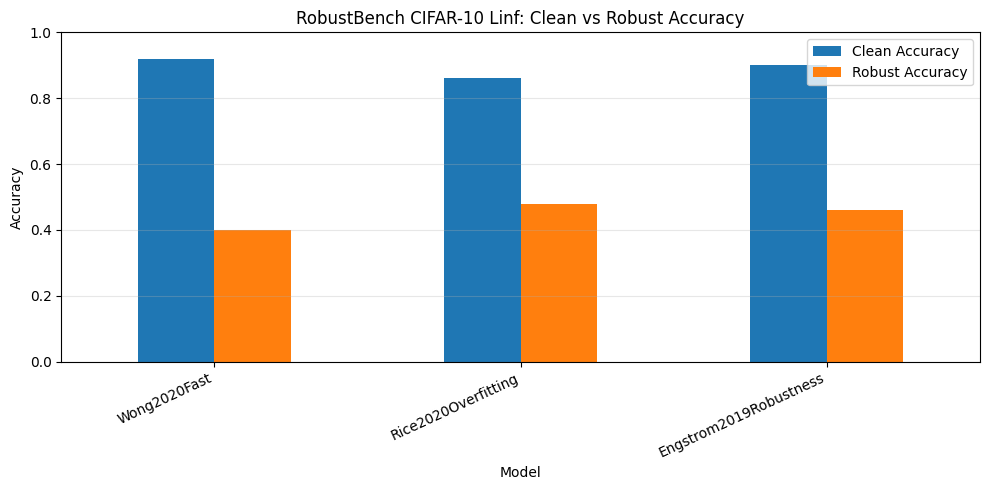

In [10]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Clean Accuracy", "Robust Accuracy"]]
ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("RobustBench CIFAR-10 Linf: Clean vs Robust Accuracy")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

fig_path = OUTPUT_DIR / "robustbench_3_models_linf_plot.png"
plt.savefig(fig_path, dpi=200)
print("Saved figure:", fig_path)
plt.show()

## 8. Slide Text Template

Use this text after you get the final numbers.

**Slide: Goal**

We evaluated three models from the RobustBench CIFAR-10 Linf leaderboard to compare their clean accuracy and adversarial robustness under the same standardized attack setting.

**Slide: Method**

- Dataset: CIFAR-10
- Threat model: Linf
- Perturbation budget: ε = 8/255
- Attack: AutoAttack standard version
- Models: Wong2020Fast, Rice2020Overfitting, Engstrom2019Robustness
- Evaluation subset: `N_EXAMPLES` test images

**Slide: Results**

Insert the CSV table generated by this notebook.

**Slide: Interpretation**

Clean accuracy measures performance on unmodified test images. Robust accuracy measures performance after AutoAttack. A larger drop between clean and robust accuracy means the model is more vulnerable under this Linf threat model.